# Set up

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod

In [3]:
SEED = 42
LEARNING_RATE = 0.01
MAX_ITER = 10000

---
# [1] Phân tích và Tiền xử lý Dữ liệu

## 1.1 Load dữ liệu

In [4]:
data_path = Path().resolve().parent.parent / 'data' / 'london_merged.csv'
df = pd.read_csv(data_path)

print(f'Shape: {df.shape}')
df.head()

Shape: (17414, 10)


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [6]:
df.describe()

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


## 1.2 Xử lý giá trị còn thiếu (Missing Values)

In [7]:
# Check for missing values in the dataset

missing_counts = df.isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})

print("Missing values summary:")
print(missing_summary)

total_missing = missing_counts.sum()
print(f"\nTotal number of missing values: {total_missing}")

Missing values summary:
              Missing Count  Missing Percentage (%)
timestamp                 0                     0.0
cnt                       0                     0.0
t1                        0                     0.0
t2                        0                     0.0
hum                       0                     0.0
wind_speed                0                     0.0
weather_code              0                     0.0
is_holiday                0                     0.0
is_weekend                0                     0.0
season                    0                     0.0

Total number of missing values: 0


In [8]:
# Handle missing values: fill numeric columns with median

if missing_counts.sum() > 0:
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        missing_before = df[col].isnull().sum()

        if missing_before > 0:
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

            print(f"{col}: filled {missing_before} missing values with median = {median_value:.2f}")

    print("\nMissing values after processing:")
    print(df.isnull().sum())

else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


## 1.3 Khám phá dữ liệu (EDA)

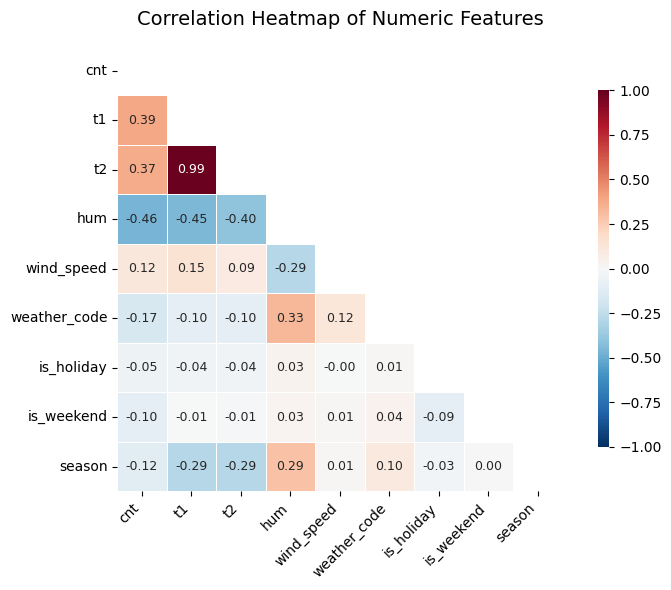

In [9]:
# Select only numeric columns (safer than hard-dropping specific columns)
numeric_df = df.select_dtypes(include=np.number)

if numeric_df.empty:
    print("No numeric columns found for correlation calculation.")
else:
    corr_matrix = numeric_df.corr()

    # Mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(max(8, len(corr_matrix.columns) * 0.7), 
                         max(6, len(corr_matrix.columns) * 0.65)))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.6,
        cbar_kws={'shrink': 0.8, 'aspect': 30},
        annot_kws={'size': 9},
    )

    plt.title('Correlation Heatmap of Numeric Features', fontsize=14, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

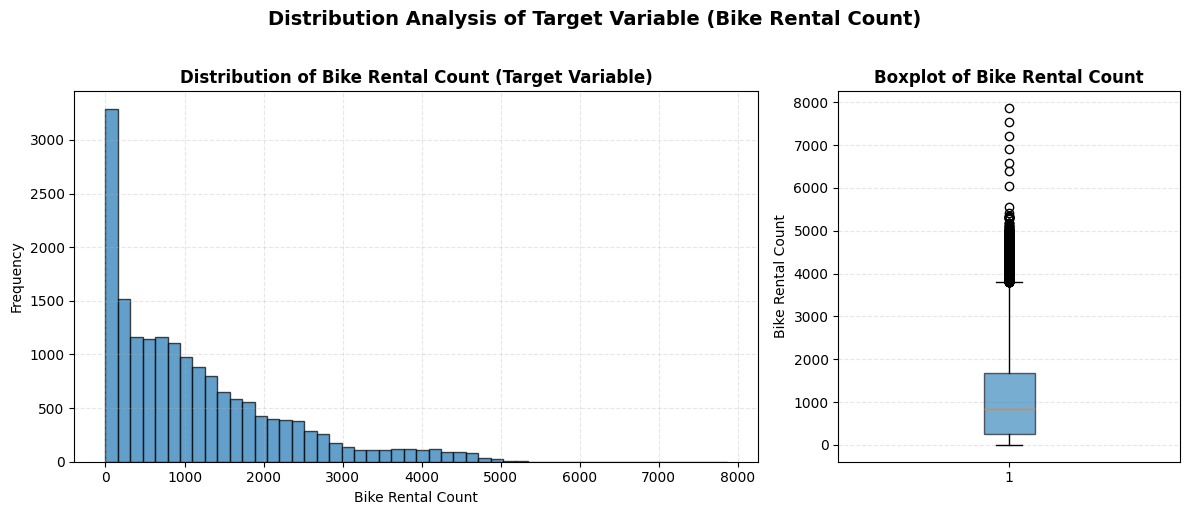

In [10]:
# Distribution of the target variable 'cnt'
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]})

# Histogram
axes[0].hist(df['cnt'], bins=50, edgecolor='black', alpha=0.7, color='#1f77b4')
axes[0].set_title('Distribution of Bike Rental Count (Target Variable)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bike Rental Count')          
axes[0].set_ylabel('Frequency')                  
axes[0].grid(True, alpha=0.3, linestyle='--')

# Boxplot
axes[1].boxplot(df['cnt'], patch_artist=True, boxprops=dict(facecolor='#1f77b4', alpha=0.6))
axes[1].set_title('Boxplot of Bike Rental Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bike Rental Count')          
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Distribution Analysis of Target Variable (Bike Rental Count)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.4 Chuẩn hóa (Standardization)

In [11]:
from sklearn.preprocessing import StandardScaler

# Tách features và target
feature_names = [col for col in df.columns if col not in ('timestamp', 'cnt')]
X = df[feature_names].values
y = df['cnt'].values

print(f'Features ({len(feature_names)}): {feature_names}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# StandardScaler: mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nAfter standardization:')
print(f'  Mean ≈ {X_scaled.mean(axis=0).round(4)}')
print(f'  Std  ≈ {X_scaled.std(axis=0).round(4)}')

Features (8): ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']
X shape: (17414, 8)
y shape: (17414,)

After standardization:
  Mean ≈ [-0. -0. -0.  0.  0.  0.  0.  0.]
  Std  ≈ [1. 1. 1. 1. 1. 1. 1. 1.]


## 1.5 Chia dữ liệu: Train (70%) / Validation (10%) / Test (20%)

In [12]:
from sklearn.model_selection import train_test_split

# Split data: 70% train, 10% validation, 20% test
# First split: 70% train + 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.30,
    random_state=SEED
)

# Then split temp set: ~1/3 val (10% total), ~2/3 test (20% total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=2/3,  # 2/3 of temp set → test, 1/3 → val
    random_state=SEED
)


assert X_train.shape[0] == len(y_train), "Train X and y mismatch"
assert X_val.shape[0] == len(y_val), "Val X and y mismatch"
assert X_test.shape[0] == len(y_test), "Test X and y mismatch"

total_samples = len(y)
print(f"Train set : {X_train.shape[0]:>6} samples ({X_train.shape[0]/total_samples*100:5.1f}%)")
print(f"Val set   : {X_val.shape[0]:>6} samples ({X_val.shape[0]/total_samples*100:5.1f}%)")
print(f"Test set  : {X_test.shape[0]:>6} samples ({X_test.shape[0]/total_samples*100:5.1f}%)")
print(f"Total     : {total_samples:>6} samples")

Train set :  12189 samples ( 70.0%)
Val set   :   1741 samples ( 10.0%)
Test set  :   3484 samples ( 20.0%)
Total     :  17414 samples


---
# Model

## Base

In [13]:
class Regression(ABC):
    """Abstract base class for regression models."""

    @abstractmethod
    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """Fit the model to the training data."""
        pass

    @abstractmethod
    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict target values for given input."""
        pass

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> dict:
        """Compute MSE, RMSE, MAE, R2."""
        mse = np.mean((y_hat - y) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_hat - y))
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
        return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

---

## [2] Hồi Quy Với Regularization: Kiểm Soát Độ Phức Tạp & Chọn Feature

**Mục đích:** 
- Tìm hiểu cách **kiểm soát độ phức tạp** của mô hình để tránh overfitting
- So sánh các phương pháp regularization (L1, L2, L1+L2)
- Tìm ra **feature nào thực sự quan trọng** cho dự đoán

**Nội dung:**
- **[2.1]** Ridge (L2) vs Lasso (L1): Chọn tham số tối ưu bằng k-fold CV
- **[2.2]** Regularization Path: Thấy rõ cách hệ số thay đổi
- **[2.3]** Elastic Net: Kết hợp cả L1 và L2
- **[2.4]** Feature Selection: So sánh 3 cách chọn feature

### Linear Regression

In [14]:
class LinearRegression(Regression):
    """Linear Regression using Normal Equation or Gradient Descent."""

    def __init__(self, solver: str = 'normal',
                 learning_rate: float = LEARNING_RATE,
                 max_iter: int = MAX_ITER,
                 random_state: int = SEED):
        self.solver = solver
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        if self.solver == 'normal':
            self._fit_normal_equation(X, y)
        else:
            self._fit_gradient_descent(X, y)

    def _fit_normal_equation(self, X: np.ndarray, y: np.ndarray) -> None:
        """Closed-form: θ = (XᵀX)⁻¹ Xᵀy"""
        X_b = np.c_[np.ones(X.shape[0]), X]
        theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

    def _fit_gradient_descent(self, X: np.ndarray, y: np.ndarray) -> None:
        """Batch gradient descent."""
        np.random.seed(self.random_state)
        n, d = X.shape
        self.coef_ = np.random.randn(d) * 0.01
        self.intercept_ = 0.0
        self.loss_history_ = []

        for _ in range(self.max_iter):
            error = X @ self.coef_ + self.intercept_ - y
            self.coef_ -= self.learning_rate * (2 / n) * (X.T @ error)
            self.intercept_ -= self.learning_rate * (2 / n) * np.sum(error)
            self.loss_history_.append(np.mean(error ** 2))

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_ + self.intercept_

### Ridge Regression (L2 Regularization)

In [15]:
class RidgeRegression(Regression):
    """Ridge Regression (L2): θ = (XᵀX + αI)⁻¹ Xᵀy"""

    def __init__(self, alpha: float = 1.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        X_b = np.c_[np.ones(X.shape[0]), X]
        d = X_b.shape[1]
        reg = self.alpha * np.eye(d)
        reg[0, 0] = 0  # không regularize bias
        theta = np.linalg.pinv(X_b.T @ X_b + reg) @ X_b.T @ y
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_ + self.intercept_

### Lasso Regression (L1 — Feature Selection)

In [16]:
class LassoRegression(Regression):
    """Lasso (L1) using Coordinate Descent with Soft-Thresholding."""

    def __init__(self, alpha: float = 1.0, max_iter: int = 500):
        self.alpha = alpha
        self.max_iter = max_iter
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        n, d = X.shape
        self.coef_ = np.zeros(d)
        self.intercept_ = np.mean(y)

        for _ in range(self.max_iter):
            for j in range(d):
                # Partial residual excluding feature j
                r_j = y - self.intercept_ - X @ self.coef_ + X[:, j] * self.coef_[j]
                rho = X[:, j] @ r_j / n
                z = np.sum(X[:, j] ** 2) / n
                # Soft-thresholding operator
                self.coef_[j] = np.sign(rho) * max(abs(rho) - self.alpha / 2, 0) / z
            self.intercept_ = np.mean(y - X @ self.coef_)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_ + self.intercept_

In [17]:

# K-Fold Cross-Validation (manual implementation)


def k_fold_cv(model_class, model_params, X, y, k=10):
    """
    Manual k-fold cross-validation.
    Returns (mean_mse, std_mse).
    """
    n = len(y)
    fold_size = n // k
    indices = np.arange(n)
    np.random.seed(SEED)
    np.random.shuffle(indices)

    mse_scores = []
    for i in range(k):
        val_start = i * fold_size
        val_end = val_start + fold_size if i < k - 1 else n

        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_vl, y_vl = X[val_idx], y[val_idx]

        model = model_class(**model_params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_vl)
        mse = np.mean((y_pred - y_vl) ** 2)
        mse_scores.append(mse)

    return np.mean(mse_scores), np.std(mse_scores)

print('k_fold_cv() ready.')


k_fold_cv() ready.


In [18]:


# Elastic Net (L1 + L2 Regularization)


class ElasticNetRegression(Regression):
    """Elastic Net: E(w) = 1/2 ||t - Φw||² + λ1||w||_1 + λ2/2 ||w||²
    Sử dụng Coordinate Descent với Soft-Thresholding.
    """

    def __init__(self, lambda1: float = 1.0, lambda2: float = 1.0,
                 max_iter: int = 500):
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.max_iter = max_iter
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        n, d = X.shape
        self.coef_ = np.zeros(d)
        self.intercept_ = np.mean(y)

        for _ in range(self.max_iter):
            for j in range(d):
                r_j = (y - self.intercept_ - X @ self.coef_
                       + X[:, j] * self.coef_[j])
                rho = X[:, j] @ r_j / n
                z = np.sum(X[:, j] ** 2) / n + 2 * self.lambda2
                # Soft-thresholding + L2
                self.coef_[j] = (np.sign(rho)
                                 * max(abs(rho) - self.lambda1 / 2, 0) / z)
            self.intercept_ = np.mean(y - X @ self.coef_)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_ + self.intercept_

print('ElasticNetRegression() ready.')


ElasticNetRegression() ready.


In [19]:


# Regularization Path Functions (Warm Start)


def compute_ridge_path(X, y, alphas):
    """Compute Ridge regularization path."""
    coefs = []
    for alpha in alphas:
        model = RidgeRegression(alpha=alpha)
        model.fit(X, y)
        coefs.append(model.coef_.copy())
    return np.array(coefs)


def compute_lasso_path(X, y, alphas, max_iter=1000):
    """Compute Lasso regularization path với warm start.
    alphas phải được sắp xếp GIẢM DẦN để warm start hiệu quả.
    """
    n, d = X.shape
    coefs = []
    current_coef = np.zeros(d)
    current_intercept = np.mean(y)

    for alpha in alphas:
        # Coordinate descent (warm start từ nghiệm trước)
        for _ in range(max_iter):
            for j in range(d):
                r_j = (y - current_intercept - X @ current_coef
                       + X[:, j] * current_coef[j])
                rho = X[:, j] @ r_j / n
                z = np.sum(X[:, j] ** 2) / n
                current_coef[j] = (np.sign(rho)
                                   * max(abs(rho) - alpha / 2, 0) / z)
            current_intercept = np.mean(y - X @ current_coef)
        coefs.append(current_coef.copy())

    return np.array(coefs)

print('compute_ridge_path() và compute_lasso_path() ready.')


compute_ridge_path() và compute_lasso_path() ready.


### [2.1] Ridge & Lasso: Cài đặt và Chọn Tham Số Tối Ưu (k-fold CV)

Phần này so sánh hai phương pháp regularization phổ biến:

**Ridge Regression (L2):** Thu nhỏ tất cả các hệ số về phía 0, nhưng không loại bỏ hoàn toàn các feature.  
**Lasso Regression (L1):** Có khả năng loại bỏ hoàn toàn một số feature (đặt hệ số = 0 chính xác).

Quy trình:
1. Thử các giá trị tham số (λ) khác nhau
2. Dùng k-fold cross-validation (k=10) để tìm λ tốt nhất
3. Huấn luyện mô hình cuối cùng với λ tối ưu
4. So sánh hệ số giữa Linear Regression, Ridge, và Lasso

In [20]:
# Linear Regression (baseline)
lr = LinearRegression(solver='normal')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
m_lr = lr.evaluate(y_pred_lr, y_test)
print('Linear Regression:', m_lr)

Linear Regression: {'MSE': np.float64(840354.991786768), 'RMSE': np.float64(916.7087824313498), 'MAE': np.float64(679.0443884760457), 'R2': np.float64(0.2664039911633074)}


In [21]:
# Ridge — tune alpha using k-fold CV (k=10)
print('--- Ridge tuning (k-fold CV, k=10) ---')
best_ridge = None
best_alpha_ridge = None
best_mse_ridge = float('inf')
best_std_ridge = 0

for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0, 5000.0]:
    mean_mse, std_mse = k_fold_cv(RidgeRegression, {'alpha': alpha}, X_train, y_train, k=10)
    print(f'  alpha = {alpha:<6}  CV MSE = {mean_mse:.2f} ± {std_mse:.2f}')
    if mean_mse < best_mse_ridge:
        best_mse_ridge = mean_mse
        best_std_ridge = std_mse
        best_alpha_ridge = alpha

# Train final Ridge model with best alpha on full training set
best_ridge = RidgeRegression(alpha=best_alpha_ridge)
best_ridge.fit(X_train, y_train)

y_pred_ridge = best_ridge.predict(X_test)
m_ridge = best_ridge.evaluate(y_pred_ridge, y_test)
print(f'\nBest Ridge (alpha={best_alpha_ridge}): CV MSE = {best_mse_ridge:.2f} ± {best_std_ridge:.2f}')
print(f'Best Ridge Test performance: {m_ridge}')

--- Ridge tuning (k-fold CV, k=10) ---
  alpha = 0.1     CV MSE = 852120.34 ± 53788.48
  alpha = 1.0     CV MSE = 852119.62 ± 53795.37
  alpha = 10.0    CV MSE = 852120.13 ± 53857.91
  alpha = 100.0   CV MSE = 852335.71 ± 54170.21
  alpha = 1000.0  CV MSE = 854486.41 ± 54658.79
  alpha = 5000.0  CV MSE = 871810.81 ± 56654.72

Best Ridge (alpha=1.0): CV MSE = 852119.62 ± 53795.37
Best Ridge Test performance: {'MSE': np.float64(840360.9174203388), 'RMSE': np.float64(916.712014440925), 'MAE': np.float64(679.0483935689674), 'R2': np.float64(0.2663988183242335)}


In [22]:
# Lasso — tune alpha using k-fold CV (k=10) + feature selection
print('--- Lasso tuning (k-fold CV, k=10) ---')
best_lasso = None
best_alpha_lasso = None
best_mse_lasso = float('inf')
best_std_lasso = 0

for alpha in [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]:
    mean_mse, std_mse = k_fold_cv(LassoRegression, {'alpha': alpha}, X_train, y_train, k=10)
    # Count non-zero features for this alpha (using a temporary model)
    temp_model = LassoRegression(alpha=alpha)
    temp_model.fit(X_train, y_train)
    n_kept = np.count_nonzero(temp_model.coef_)
    print(f'  alpha = {alpha:<5}  CV MSE = {mean_mse:.2f} ± {std_mse:.2f}  features kept = {n_kept}/{len(feature_names)}')
    if mean_mse < best_mse_lasso:
        best_mse_lasso = mean_mse
        best_std_lasso = std_mse
        best_alpha_lasso = alpha

# Train final Lasso model with best alpha on full training set
best_lasso = LassoRegression(alpha=best_alpha_lasso)
best_lasso.fit(X_train, y_train)

y_pred_lasso = best_lasso.predict(X_test)
m_lasso = best_lasso.evaluate(y_pred_lasso, y_test)
print(f'\nBest Lasso (alpha={best_alpha_lasso}): CV MSE = {best_mse_lasso:.2f} ± {best_std_lasso:.2f}')
print(f'Best Lasso Test performance: {m_lasso}')
print(f'Coefficients: {dict(zip(feature_names, best_lasso.coef_.round(4)))}')
print(f'Dropped features: {[f for f, c in zip(feature_names, best_lasso.coef_) if c == 0]}')

--- Lasso tuning (k-fold CV, k=10) ---
  alpha = 0.01   CV MSE = 852120.46 ± 53790.07  features kept = 8/8
  alpha = 0.1    CV MSE = 852121.23 ± 53811.13  features kept = 8/8
  alpha = 1.0    CV MSE = 852178.16 ± 54023.57  features kept = 8/8
  alpha = 5.0    CV MSE = 852290.48 ± 54268.71  features kept = 7/8
  alpha = 10.0   CV MSE = 852437.26 ± 54476.20  features kept = 7/8
  alpha = 20.0   CV MSE = 853025.31 ± 54894.01  features kept = 7/8
  alpha = 50.0   CV MSE = 856523.34 ± 55898.46  features kept = 6/8
  alpha = 100.0  CV MSE = 865080.28 ± 56898.53  features kept = 3/8

Best Lasso (alpha=0.01): CV MSE = 852120.46 ± 53790.07
Best Lasso Test performance: {'MSE': np.float64(840356.349048689), 'RMSE': np.float64(916.7095227217229), 'MAE': np.float64(679.0449081721256), 'R2': np.float64(0.26640280632840074)}
Coefficients: {'t1': np.float64(370.3881), 't2': np.float64(-104.3456), 'hum': np.float64(-400.1158), 'wind_speed': np.float64(-31.7453), 'weather_code': np.float64(-16.4761), 'i


DETAILED COEFFICIENT COMPARISON
Feature                  Linear        Ridge        Lasso     Δ Ridge%     Δ Lasso%   Lasso Zero
----------------------------------------------------------------------------------------------------
t1                     370.9337     368.9129     370.3881         -0.5         -0.1           NO
t2                    -104.8807    -102.9021    -104.3456          1.9          0.5           NO
hum                   -400.0997    -400.1433    -400.1158         -0.0         -0.0           NO
wind_speed             -31.7765     -31.6691     -31.7453          0.3          0.1           NO
weather_code           -16.4821     -16.4820     -16.4761          0.0          0.0           NO
is_holiday             -35.9985     -36.0002     -35.9943         -0.0          0.0           NO
is_weekend             -88.4996     -88.4889     -88.4934          0.0          0.0           NO
season                  76.1966      76.1879      76.1921         -0.0         -0.0       

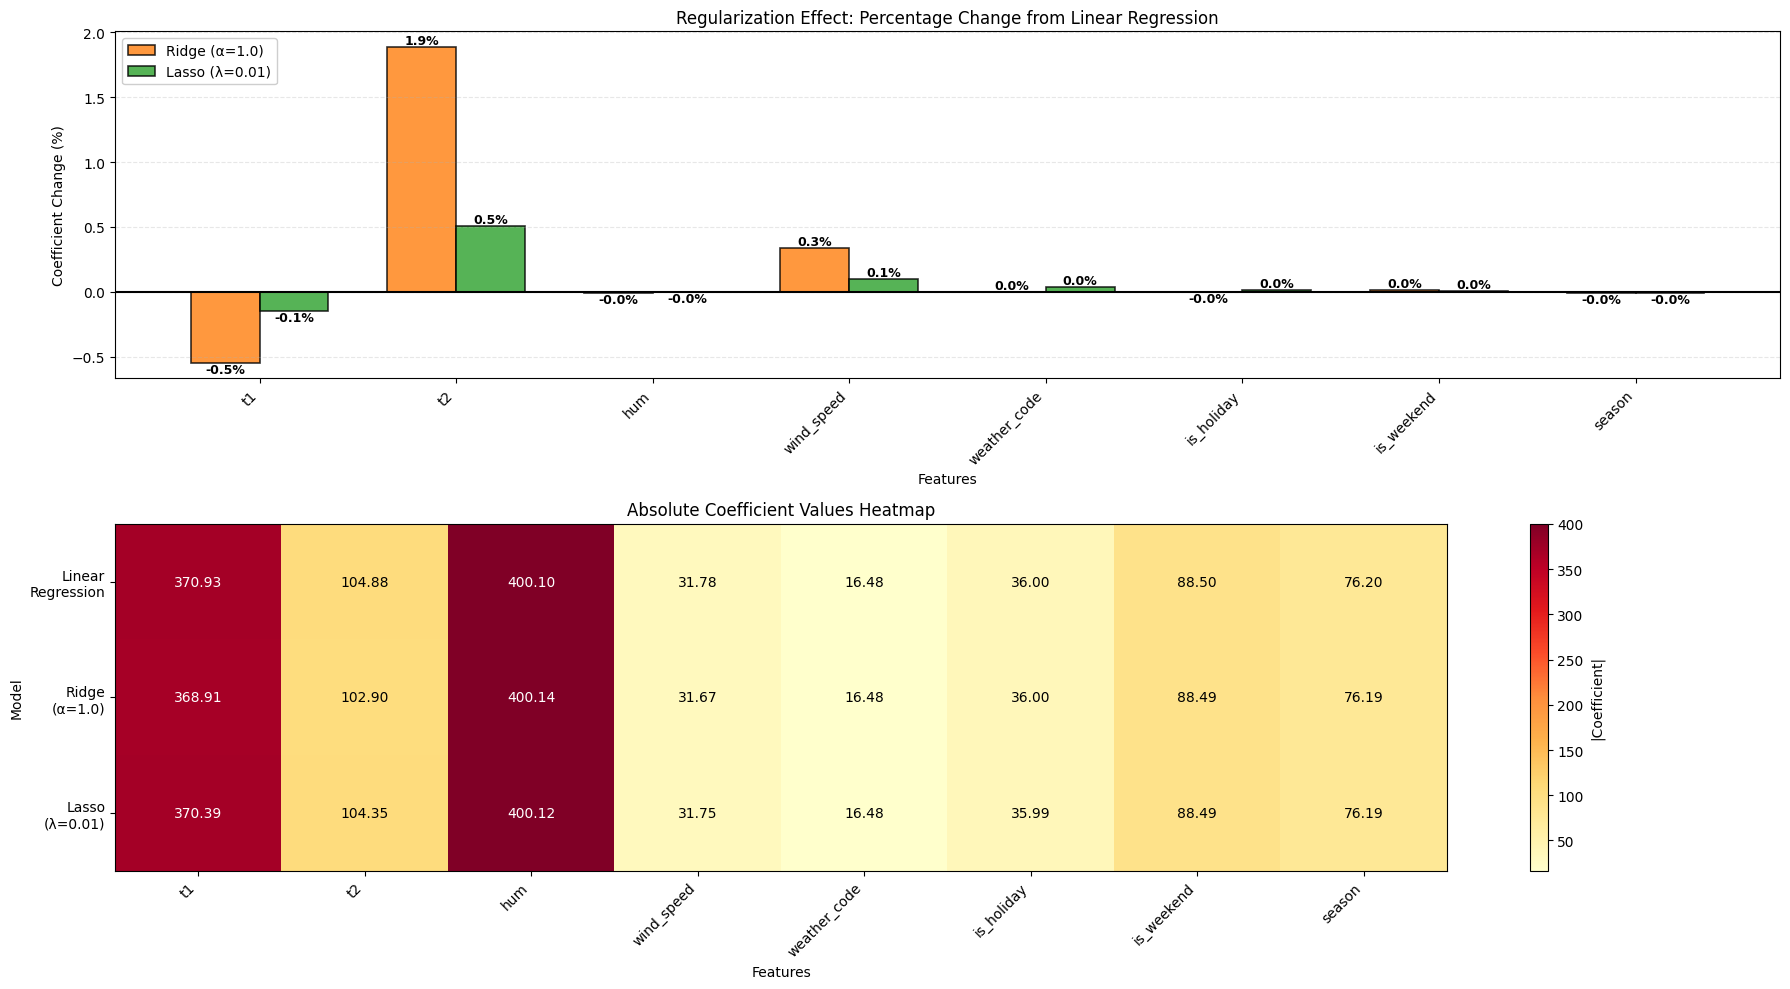

In [23]:
# === % Change + Heatmap Analysis (Linear vs Ridge vs Lasso) ===

# ===== 1. Percentage change relative to Linear Regression =====
eps = 1e-10
linear_coef = lr.coef_

pct_change_ridge = (best_ridge.coef_ - linear_coef) / (np.abs(linear_coef) + eps) * 100
pct_change_lasso = (best_lasso.coef_ - linear_coef) / (np.abs(linear_coef) + eps) * 100

# ===== 2. Visualization =====
fig = plt.figure(figsize=(18, 10))

# --- Subplot 1: Percentage Change ---
ax1 = plt.subplot(2, 1, 1)

x = np.arange(len(feature_names))
width = 0.35

bars_ridge = ax1.bar(
    x - width / 2,
    pct_change_ridge,
    width,
    label=f'Ridge (α={best_alpha_ridge})',
    color='#ff7f0e',
    alpha=0.8,
    edgecolor='black',
    linewidth=1.2
)

bars_lasso = ax1.bar(
    x + width / 2,
    pct_change_lasso,
    width,
    label=f'Lasso (λ={best_alpha_lasso})',
    color='#2ca02c',
    alpha=0.8,
    edgecolor='black',
    linewidth=1.2
)

ax1.set(
    xlabel='Features',
    ylabel='Coefficient Change (%)',
    title='Regularization Effect: Percentage Change from Linear Regression'
)

ax1.set_xticks(x)
ax1.set_xticklabels(feature_names, rotation=45, ha='right')
ax1.axhline(0, color='black', linewidth=1.5)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax1.legend(loc='upper left', framealpha=0.95)

# Annotate bars
for bars in (bars_ridge, bars_lasso):
    for bar in bars:
        value = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f'{value:.1f}%',
            ha='center',
            va='bottom' if value > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

# --- Subplot 2: Heatmap of absolute coefficients ---
ax2 = plt.subplot(2, 1, 2)

coef_matrix = np.vstack([
    np.abs(linear_coef),
    np.abs(best_ridge.coef_),
    np.abs(best_lasso.coef_)
])

model_labels = [
    'Linear\nRegression',
    f'Ridge\n(α={best_alpha_ridge})',
    f'Lasso\n(λ={best_alpha_lasso})'
]

im = ax2.imshow(coef_matrix, cmap='YlOrRd', aspect='auto')

ax2.set_xticks(np.arange(len(feature_names)))
ax2.set_yticks(np.arange(len(model_labels)))

ax2.set_xticklabels(feature_names, rotation=45, ha='right')
ax2.set_yticklabels(model_labels)

ax2.set(
    xlabel='Features',
    ylabel='Model',
    title='Absolute Coefficient Values Heatmap'
)

# Annotate heatmap
threshold = coef_matrix.max() * 0.5
for i in range(coef_matrix.shape[0]):
    for j in range(coef_matrix.shape[1]):
        value = coef_matrix[i, j]
        color = 'white' if value > threshold else 'black'
        ax2.text(j, i, f'{value:.2f}', ha='center', va='center', color=color)

plt.colorbar(im, ax=ax2, label='|Coefficient|')

plt.tight_layout()

# ===== 3. Detailed comparison table =====
print('\n' + '=' * 100)
print('DETAILED COEFFICIENT COMPARISON')
print('=' * 100)

header = f'{"Feature":<18} {"Linear":>12} {"Ridge":>12} {"Lasso":>12} {"Δ Ridge%":>12} {"Δ Lasso%":>12} {"Lasso Zero":>12}'
print(header)
print('-' * 100)

for i, feat in enumerate(feature_names):
    lin = linear_coef[i]
    ridge = best_ridge.coef_[i]
    lasso = best_lasso.coef_[i]

    print(
        f'{feat:<18} {lin:>12.4f} {ridge:>12.4f} {lasso:>12.4f} '
        f'{pct_change_ridge[i]:>12.1f} {pct_change_lasso[i]:>12.1f} '
        f'{"YES ✓" if abs(lasso) < eps else "NO":>12}'
    )

# ===== 4. Summary statistics =====
print('\n' + '=' * 100)
print('SUMMARY STATISTICS')
print('=' * 100)

ridge_avg = np.mean(np.abs(pct_change_ridge))
lasso_avg = np.mean(np.abs(pct_change_lasso))
ridge_max = np.max(np.abs(pct_change_ridge))
lasso_max = np.max(np.abs(pct_change_lasso))

lasso_zero_count = np.sum(np.abs(best_lasso.coef_) < eps)

print('\nRIDGE (L2):')
print(f'Average shrinkage: {ridge_avg:.2f}%')
print(f'Maximum shrinkage: {ridge_max:.2f}% ({feature_names[np.argmax(np.abs(pct_change_ridge))]})')
print('All coefficients non-zero: Yes')

print('\nLASSO (L1):')
print(f'Average shrinkage: {lasso_avg:.2f}%')
print(f'Maximum shrinkage: {lasso_max:.2f}% ({feature_names[np.argmax(np.abs(pct_change_lasso))]})')
print(f'Zero coefficients: {lasso_zero_count}/{len(feature_names)} ({lasso_zero_count/len(feature_names)*100:.1f}%)')

if lasso_zero_count > 0:
    eliminated_features = [f for f, c in zip(feature_names, best_lasso.coef_) if abs(c) < eps]
    print(f'Eliminated features: {eliminated_features}')
else:
    print('Eliminated features: None')

print('\nINTERPRETATION:')
if ridge_avg < 10 and lasso_avg < 10:
    print('Minimal regularization effect (<10% change)')
    print('Linear model is already well-fitted')
else:
    print('Regularization significantly affects coefficients')

print('\nMODEL PERFORMANCE:')
print(f'Linear MSE: {m_lr["MSE"]:.2f}')
print(f'Ridge MSE:  {m_ridge["MSE"]:.2f} ({(m_ridge["MSE"]/m_lr["MSE"]-1)*100:+.2f}%)')
print(f'Lasso MSE:  {m_lasso["MSE"]:.2f} ({(m_lasso["MSE"]/m_lr["MSE"]-1)*100:+.2f}%)')

print('=' * 100)

### [2.2] Regularization Path: Theo dõi Hệ Số Khi λ Thay Đổi

Mục đích: Hiểu rõ **cách hệ số thay đổi** khi tăng sức mạnh của regularization (λ từ nhỏ đến lớn).

**Ridge path:**
- Hệ số giảm dần một cách mượt mà
- Không bao giờ bằng 0 chính xác (chỉ sát 0)

**Lasso path:**
- Hệ số giảm không đều đặn (gợi sóng)
- Một số hệ số nhảy thẳng bằng 0 khi λ vượt ngưỡng nào đó
- Dùng "warm start": dùng nghiệm cũ để tính manh nghiệm mới → nhanh hơn

So sánh hai path giúp bạn thấy sự khác biệt giữa L2 (mềm) và L1 (cứng).

Ridge path computed for 80 alphas
Lasso path computed (warm start) for 80 alphas


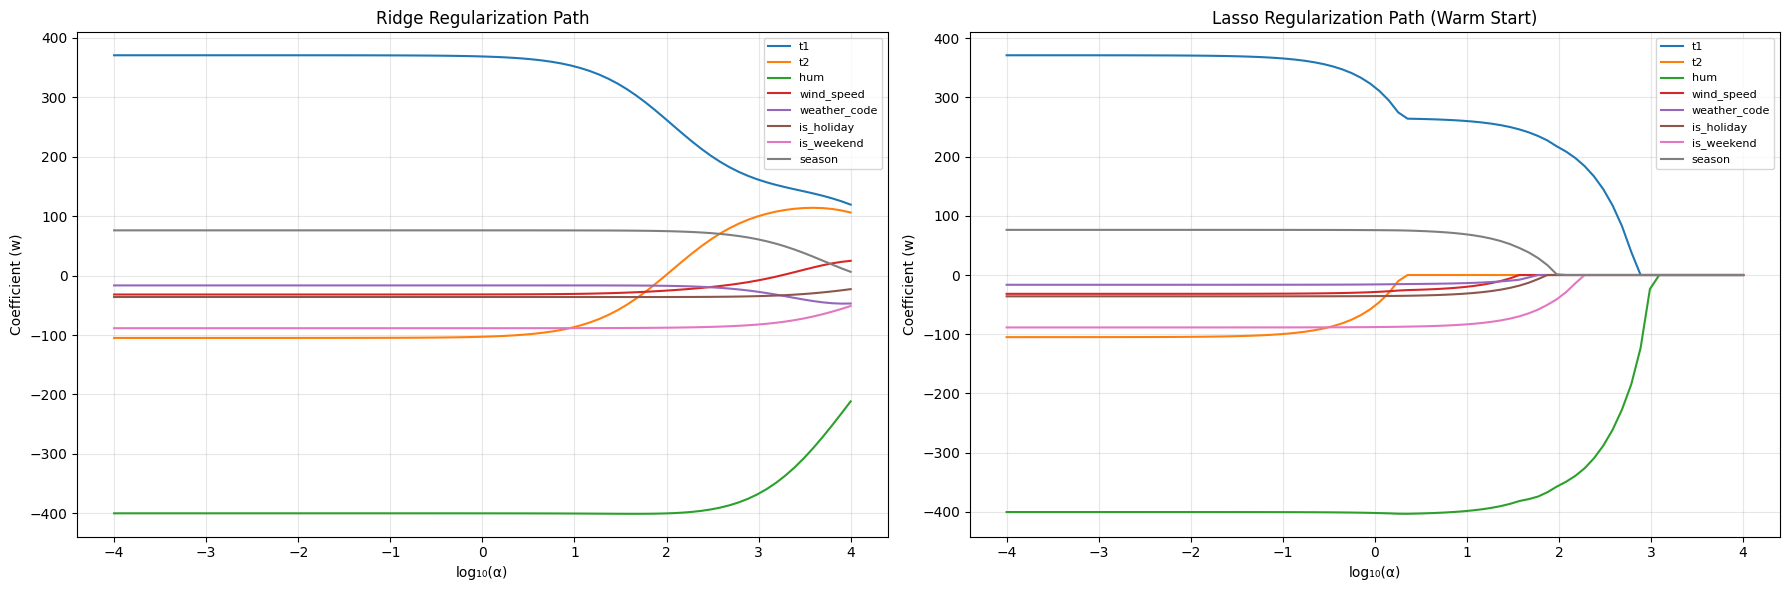

In [24]:
# Regularization Path cho Ridge và Lasso
alphas_plot = np.logspace(-4, 4, 80)

# Ridge path
ridge_coefs = compute_ridge_path(X_train, y_train, alphas_plot)

# Lasso path (warm start — alphas giảm dần)
alphas_lasso_desc = alphas_plot[::-1]
lasso_coefs_desc = compute_lasso_path(X_train, y_train, alphas_lasso_desc,
                                       max_iter=500)
lasso_coefs = lasso_coefs_desc[::-1]  # đảo lại cho đồng bộ alphas_plot

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Ridge
for i, name in enumerate(feature_names):
    axes[0].plot(np.log10(alphas_plot), ridge_coefs[:, i], label=name)
axes[0].set_xlabel('log₁₀(α)')
axes[0].set_ylabel('Coefficient (w)')
axes[0].set_title('Ridge Regularization Path')
axes[0].legend(fontsize=8, loc='best')
axes[0].grid(alpha=0.3)

# Lasso
for i, name in enumerate(feature_names):
    axes[1].plot(np.log10(alphas_plot), lasso_coefs[:, i], label=name)
axes[1].set_xlabel('log₁₀(α)')
axes[1].set_ylabel('Coefficient (w)')
axes[1].set_title('Lasso Regularization Path (Warm Start)')
axes[1].legend(fontsize=8, loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()

print(f'Ridge path computed for {len(alphas_plot)} alphas')
print(f'Lasso path computed (warm start) for {len(alphas_plot)} alphas')


### [2.3] Elastic Net: Kết Hợp L1 và L2 - Tìm Vùng Tối Ưu

Elastic Net = Ridge (L2) + Lasso (L1)

$$E(\mathbf{w}) = \frac{1}{2}\|\mathbf{t}-\Phi\mathbf{w}\|^2 + \lambda_1\|\mathbf{w}\|_1 + \frac{\lambda_2}{2}\|\mathbf{w}\|_2^2$$

Ưu điểm: Kết hợp khả năng **loại feature** (từ Lasso) + **mềm mại** (từ Ridge)

Quy trình:
1. Tạo lưới giá trị: thử tất cả cặp (λ₁, λ₂) từ 10⁻³ đến 10¹
2. Với mỗi cặp (λ₁, λ₂): huấn luyện mô hình, đánh giá trên validation set
3. Vẽ **heatmap**: điểm tối ưu sẽ là nơi MSE thấp nhất (thường trông như "vùng lõm")
4. Lấy tham số tốt nhất để huấn luyện mô hình cuối cùng

=== Elastic Net: Hyperparameter Optimization (λ1, λ2) ===
Best λ1=0.001000, λ2=0.007197, Val MSE=978718.6068

Best Elastic Net (λ1=0.001000, λ2=0.007197): {'MSE': np.float64(841061.3076044414), 'RMSE': np.float64(917.0939469893154), 'MAE': np.float64(679.7696505431347), 'R2': np.float64(0.2657874059464792)}


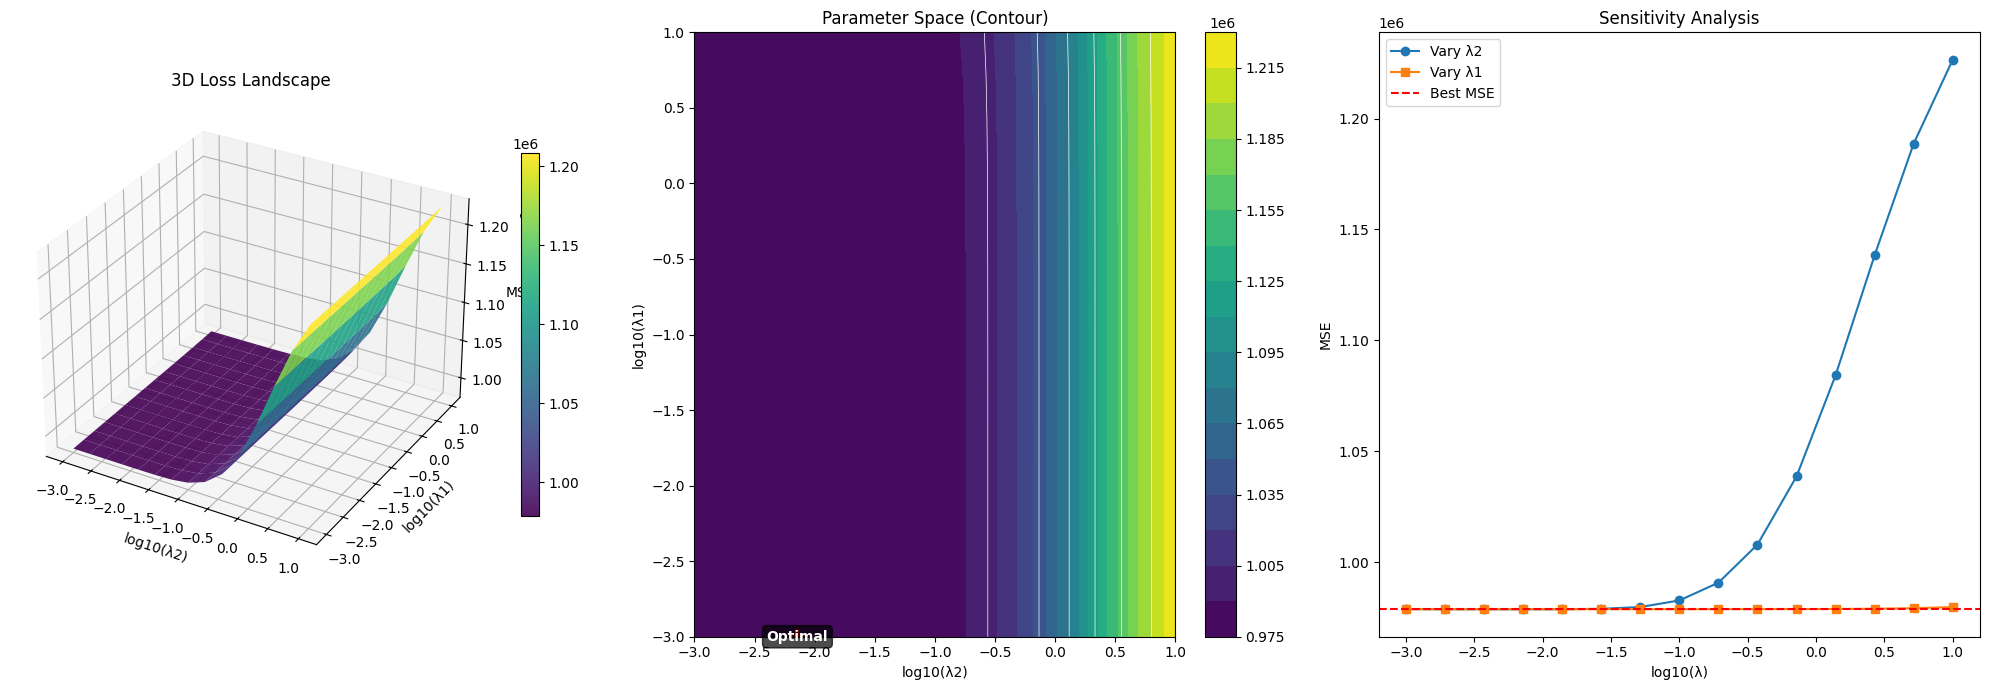

In [25]:
# Elastic Net: Hyperparameter Optimization (λ1, λ2)
print("=== Elastic Net: Hyperparameter Optimization (λ1, λ2) ===")

# Hyperparameter grid
lambda1_values = np.logspace(-3, 1, 15)
lambda2_values = np.logspace(-3, 1, 15)

mse_grid = np.zeros((len(lambda1_values), len(lambda2_values)))

# Grid search
for i, l1 in enumerate(lambda1_values):
    for j, l2 in enumerate(lambda2_values):
        model = ElasticNetRegression(lambda1=l1, lambda2=l2, max_iter=500)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        mse_grid[i, j] = np.mean((y_pred - y_val) ** 2)

# Best parameters
best_idx = np.unravel_index(np.argmin(mse_grid), mse_grid.shape)
best_l1 = lambda1_values[best_idx[0]]
best_l2 = lambda2_values[best_idx[1]]
best_mse = mse_grid[best_idx]

print(f"Best λ1={best_l1:.6f}, λ2={best_l2:.6f}, Val MSE={best_mse:.4f}")

# Log-scale transformation
log_l1 = np.log10(lambda1_values)
log_l2 = np.log10(lambda2_values)

L2_grid, L1_grid = np.meshgrid(log_l2, log_l1)

# ===== Visualization =====
fig = plt.figure(figsize=(20, 7))

# --- 1. 3D Surface ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')

surf = ax1.plot_surface(
    L2_grid, L1_grid, mse_grid,
    cmap='viridis', alpha=0.9, linewidth=0.2
)

ax1.set_xlabel('log10(λ2)')
ax1.set_ylabel('log10(λ1)')
ax1.set_zlabel('MSE')
ax1.set_title('3D Loss Landscape')

fig.colorbar(surf, ax=ax1, shrink=0.6)

# --- 2. Contour Plot ---
ax2 = fig.add_subplot(1, 3, 2)

contour = ax2.contourf(L2_grid, L1_grid, mse_grid, levels=20, cmap='viridis')
ax2.contour(L2_grid, L1_grid, mse_grid, colors='white', linewidths=0.5)

ax2.scatter(
    np.log10(best_l2),
    np.log10(best_l1),
    color='red', marker='*', s=200
)

ax2.set_xlabel('log10(λ2)')
ax2.set_ylabel('log10(λ1)')
ax2.set_title('Parameter Space (Contour)')

# Add text annotation for optimal point
ax2.text(
    np.log10(best_l2), 
    np.log10(best_l1),
    'Optimal',
    ha='center', va='center',
    fontsize=10, fontweight='bold',
    color='white',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
)

fig.colorbar(contour, ax=ax2)

# --- 3. 1D Sensitivity ---
ax3 = fig.add_subplot(1, 3, 3)
best_l1_idx, best_l2_idx = best_idx

mse_l2_slice = mse_grid[best_l1_idx, :]
mse_l1_slice = mse_grid[:, best_l2_idx]

ax3.plot(log_l2, mse_l2_slice, 'o-', label='Vary λ2')
ax3.plot(log_l1, mse_l1_slice, 's-', label='Vary λ1')
ax3.axhline(best_mse, linestyle='--', color='red', label='Best MSE')
ax3.set_xlabel('log10(λ)')
ax3.set_ylabel('MSE')
ax3.set_title('Sensitivity Analysis')
ax3.legend()

plt.tight_layout()

# ===== Final training =====
best_model = ElasticNetRegression(
    lambda1=best_l1,
    lambda2=best_l2,
    max_iter=1000
)
best_model.fit(X_train, y_train)
y_test_pred_enet = best_model.predict(X_test)
m_enet = best_model.evaluate(y_test_pred_enet, y_test)
print(f'\nBest Elastic Net (λ1={best_l1:.6f}, λ2={best_l2:.6f}): {m_enet}')

### [2.4] Lựa Chọn Feature: So Sánh 3 Chiến Lược

Mục đích: Tìm ra **tập hợp feature tốt nhất** (ít mà hiệu quả) bằng 3 phương pháp khác nhau.

**1. Forward Stepwise Selection (Xây dựng từ dưới lên):**
- Bắt đầu: không có feature nào
- Mỗi bước: thêm 1 feature tốt nhất (làm giảm MSE nhất)
- Kết thúc: khi thêm feature mới không tốt nữa

**2. Backward Elimination (Loại từ trên xuống):**
- Bắt đầu: có tất cả feature
- Mỗi bước: loại 1 feature "xấu nhất" (loại nó làm giảm MSE)
- Kết thúc: khi loại feature nào còn lại cũng làm tệ hơn

**3. Lasso-based Feature Selection:**
- Dùng tham số λ tối ưu từ Lasso ở [2.1]
- Feature được giữ = những cái có hệ số ≠ 0
- Đơn giản, nhanh, cho kết quả cụ thể

**So Sánh:** Xem 3 phương pháp chọn feature nào + số lượng bao nhiêu + MSE cuối cùng như thế nào

In [26]:
# Forward Stepwise Selection & Backward Elimination

def forward_stepwise_selection(X_tr, y_tr, X_vl, y_vl, names):
    """Forward Stepwise Selection: bắt đầu từ tập rỗng,
    mỗi bước thêm feature cho MSE validation tốt nhất.
    """
    n_features = X_tr.shape[1]
    remaining = list(range(n_features))
    selected = []
    results = []

    for step in range(n_features):
        best_mse = float('inf')
        best_feat = None

        for feat in remaining:
            candidate = selected + [feat]
            model = LinearRegression(solver='normal')
            model.fit(X_tr[:, candidate], y_tr)
            y_pred = model.predict(X_vl[:, candidate])
            mse = np.mean((y_pred - y_vl) ** 2)

            if mse < best_mse:
                best_mse = mse
                best_feat = feat

        selected.append(best_feat)
        remaining.remove(best_feat)
        results.append({
            'step': step + 1,
            'feature_added': names[best_feat],
            'features': [names[s] for s in selected],
            'val_mse': best_mse
        })

    return results


def backward_elimination(X_tr, y_tr, X_vl, y_vl, names):
    """Backward Elimination: bắt đầu với tất cả features,
    mỗi bước loại feature mà khi loại MSE validation tốt nhất.
    """
    n_features = X_tr.shape[1]
    current = list(range(n_features))
    results = []

    for step in range(n_features - 1):
        best_mse = float('inf')
        worst_feat = None

        for feat in current:
            candidate = [f for f in current if f != feat]
            model = LinearRegression(solver='normal')
            model.fit(X_tr[:, candidate], y_tr)
            y_pred = model.predict(X_vl[:, candidate])
            mse = np.mean((y_pred - y_vl) ** 2)

            if mse < best_mse:
                best_mse = mse
                worst_feat = feat

        current.remove(worst_feat)
        results.append({
            'step': step + 1,
            'feature_removed': names[worst_feat],
            'remaining': [names[s] for s in current],
            'val_mse': best_mse
        })

    return results

print('forward_stepwise_selection() và backward_elimination() ready.')


forward_stepwise_selection() và backward_elimination() ready.



 So sánh kết quả Feature Selection

--- Forward Stepwise Selection ---
  Step 1: +"hum" → Val MSE = 1053506.87
  Step 2: +"t1" → Val MSE = 1002194.91
  Step 3: +"is_weekend" → Val MSE = 985327.04
  Step 4: +"is_holiday" → Val MSE = 981800.97
  Step 5: +"weather_code" → Val MSE = 979781.89
  ...
  ► Best: 7 features → ['hum', 't1', 'is_weekend', 'is_holiday', 'weather_code', 'wind_speed', 'season']

--- Backward Elimination ---
  Step 1: -"t2" → Val MSE = 978850.96
  Step 2: -"season" → Val MSE = 978943.02
  Step 3: -"wind_speed" → Val MSE = 979781.89
  Step 4: -"weather_code" → Val MSE = 981800.97
  Step 5: -"is_holiday" → Val MSE = 985327.04
  ...
  ► Best: 7 features → ['t1', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']

--- Lasso-based Feature Selection ---
  Selected (8): ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']
  Dropped  (0): []

Feature selection comparison complete.


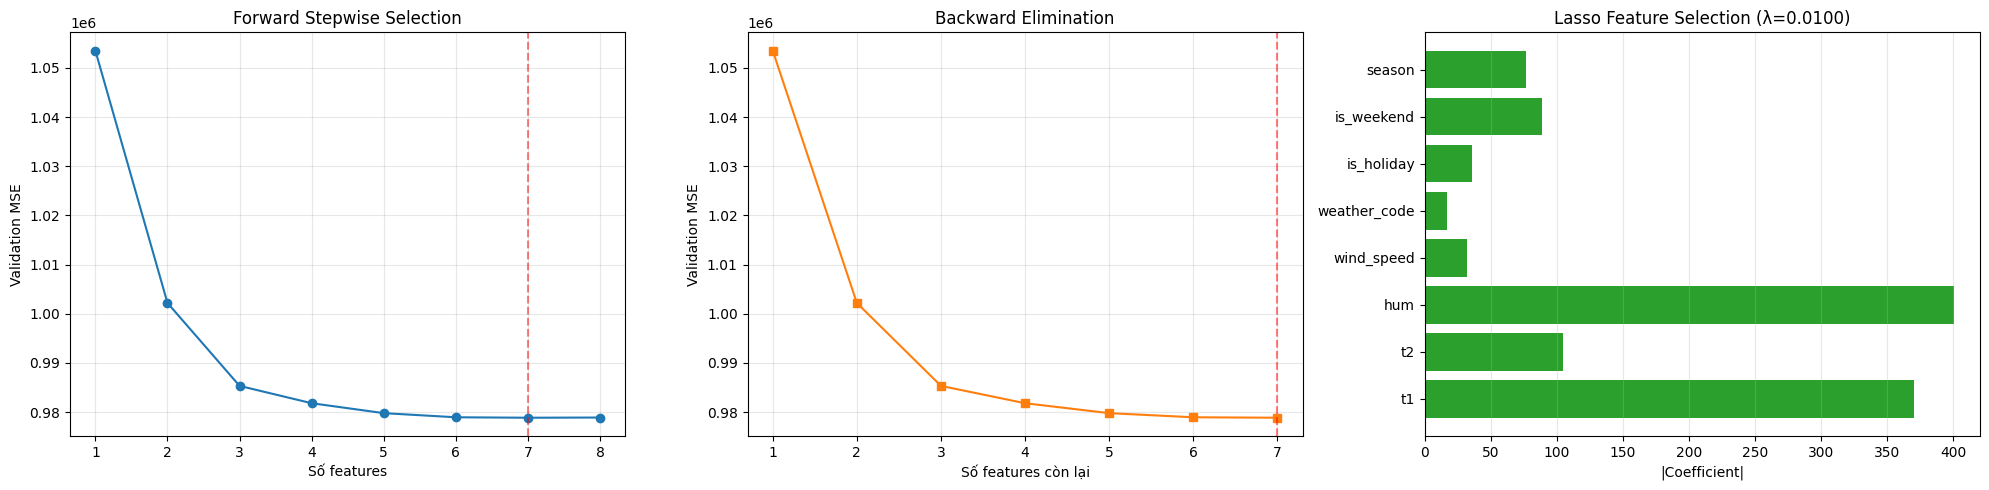

In [27]:
# So sánh 3 phương pháp Feature Selection
print('\n' + '='*60)
print(' So sánh kết quả Feature Selection')
print('='*60)

# --- Forward Stepwise ---
print('\n--- Forward Stepwise Selection ---')
fwd_results = forward_stepwise_selection(
    X_train, y_train, X_val, y_val, feature_names)
for r in fwd_results[:5]:  # Show first 5 steps
    print(f"  Step {r['step']}: +\"{r['feature_added']}\" → Val MSE = {r['val_mse']:.2f}")
best_fwd = min(fwd_results, key=lambda x: x['val_mse'])
print(f"  ...")
print(f"  ► Best: {best_fwd['step']} features → {best_fwd['features']}")

# --- Backward Elimination ---
print('\n--- Backward Elimination ---')
bwd_results = backward_elimination(
    X_train, y_train, X_val, y_val, feature_names)
for r in bwd_results[:5]:  # Show first 5 steps
    print(f"  Step {r['step']}: -\"{r['feature_removed']}\" → Val MSE = {r['val_mse']:.2f}")
best_bwd = min(bwd_results, key=lambda x: x['val_mse'])
print(f"  ...")
print(f"  ► Best: {len(best_bwd['remaining'])} features → {best_bwd['remaining']}")

# --- Lasso-based ---
print('\n--- Lasso-based Feature Selection ---')
lasso_selected = [f for f, c in zip(feature_names, best_lasso.coef_)
                  if c != 0]
lasso_dropped = [f for f, c in zip(feature_names, best_lasso.coef_)
                 if c == 0]
print(f'  Selected ({len(lasso_selected)}): {lasso_selected}')
print(f'  Dropped  ({len(lasso_dropped)}): {lasso_dropped}')

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Forward
fwd_mses = [r['val_mse'] for r in fwd_results]
axes[0].plot(range(1, len(fwd_mses)+1), fwd_mses, 'o-', markersize=6, color='#1f77b4')
axes[0].set_xlabel('Số features')
axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Forward Stepwise Selection')
axes[0].grid(alpha=0.3)
axes[0].axvline(best_fwd['step'], color='r', linestyle='--', alpha=0.5)

# Backward
bwd_mses = [r['val_mse'] for r in bwd_results]
n_feat = len(feature_names)
axes[1].plot(range(n_feat-1, 0, -1), bwd_mses, 's-', markersize=6,
             color='#ff7f0e')
axes[1].set_xlabel('Số features còn lại')
axes[1].set_ylabel('Validation MSE')
axes[1].set_title('Backward Elimination')
axes[1].grid(alpha=0.3)
axes[1].axvline(len(best_bwd['remaining']), color='r', linestyle='--', alpha=0.5)

# Lasso coefficients
colors = ['#2ca02c' if c != 0 else '#d62728'
          for c in best_lasso.coef_]
axes[2].barh(feature_names, np.abs(best_lasso.coef_), color=colors)
axes[2].set_xlabel('|Coefficient|')
axes[2].set_title(f'Lasso Feature Selection (λ={best_alpha_lasso:.4f})')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()

print('\nFeature selection comparison complete.')


### Perceptron Regression (L2) và Logistic Regression có Regularization

In [28]:
class PerceptronRegression(Regression):
    """Perceptron-style gradient descent for regression with L2 regularization."""

    def __init__(self, learning_rate: float = LEARNING_RATE,
                 max_iter: int = MAX_ITER,
                 alpha: float = 0.01,
                 random_state: int = SEED):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.alpha = alpha
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        np.random.seed(self.random_state)
        n, d = X.shape
        self.coef_ = np.random.randn(d) * 0.01
        self.intercept_ = 0.0
        self.loss_history_ = []

        for _ in range(self.max_iter):
            error = X @ self.coef_ + self.intercept_ - y
            # Gradient with L2 penalty
            self.coef_ -= self.learning_rate * (
                (2 / n) * (X.T @ error) + 2 * self.alpha * self.coef_
            )
            self.intercept_ -= self.learning_rate * (2 / n) * np.sum(error)
            loss = np.mean(error ** 2) + self.alpha * np.sum(self.coef_ ** 2)
            self.loss_history_.append(loss)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_ + self.intercept_

In [29]:
class LogisticRegressionReg:
    """Logistic Regression with L2 regularization.
    Binary classification: cnt > median → class 1, otherwise → class 0.
    """

    def __init__(self, learning_rate: float = LEARNING_RATE,
                 max_iter: int = MAX_ITER,
                 alpha: float = 0.01,
                 random_state: int = SEED):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.alpha = alpha
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        np.random.seed(self.random_state)
        n, d = X.shape
        self.coef_ = np.random.randn(d) * 0.01
        self.intercept_ = 0.0
        self.loss_history_ = []

        for _ in range(self.max_iter):
            h = self._sigmoid(X @ self.coef_ + self.intercept_)
            # Gradient with L2 penalty
            self.coef_ -= self.learning_rate * (
                (1 / n) * (X.T @ (h - y)) + 2 * self.alpha * self.coef_
            )
            self.intercept_ -= self.learning_rate * (1 / n) * np.sum(h - y)
            # Binary Cross-Entropy + L2
            eps = 1e-15
            bce = -np.mean(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
            self.loss_history_.append(bce + self.alpha * np.sum(self.coef_ ** 2))

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self._sigmoid(X @ self.coef_ + self.intercept_)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X: np.ndarray, y: np.ndarray) -> float:
        return np.mean(self.predict(X) == y)

In [30]:
# Perceptron Regression (L2)
perc = PerceptronRegression(learning_rate=0.01, max_iter=5000, alpha=0.01)
perc.fit(X_train, y_train)

y_pred_perc = perc.predict(X_test)
m_perc = perc.evaluate(y_pred_perc, y_test)
print('Perceptron Regression (L2):', m_perc)

Perceptron Regression (L2): {'MSE': np.float64(841050.723295998), 'RMSE': np.float64(917.0881764018103), 'MAE': np.float64(679.6375692006517), 'R2': np.float64(0.2657966456207911)}


In [31]:
# Logistic Regression (L2) — binary: cnt > median
median_cnt = np.median(y_train)
y_train_bin = (y_train > median_cnt).astype(int)
y_val_bin   = (y_val   > median_cnt).astype(int)
y_test_bin  = (y_test  > median_cnt).astype(int)

log_reg = LogisticRegressionReg(learning_rate=0.01, max_iter=5000, alpha=0.01)
log_reg.fit(X_train, y_train_bin)

print('Logistic Regression (L2):')
print(f'  Train accuracy = {log_reg.accuracy(X_train, y_train_bin):.4f}')
print(f'  Val   accuracy = {log_reg.accuracy(X_val, y_val_bin):.4f}')
print(f'  Test  accuracy = {log_reg.accuracy(X_test, y_test_bin):.4f}')

Logistic Regression (L2):
  Train accuracy = 0.7340
  Val   accuracy = 0.7329
  Test  accuracy = 0.7359


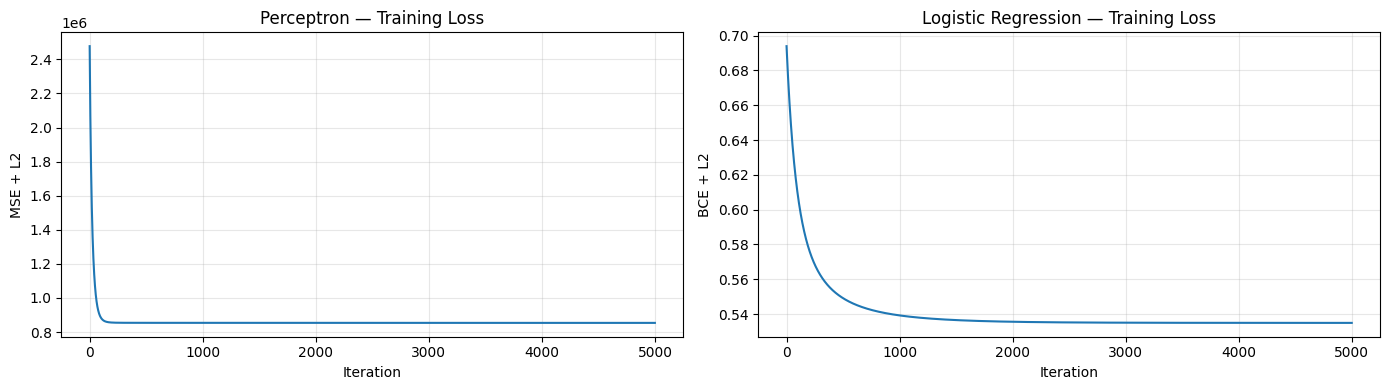

In [32]:
# Training loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(perc.loss_history_)
axes[0].set_title('Perceptron — Training Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE + L2')
axes[0].grid(alpha=0.3)

axes[1].plot(log_reg.loss_history_)
axes[1].set_title('Logistic Regression — Training Loss')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('BCE + L2')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Kernel Ridge Regression

In [33]:
class KernelRidgeRegression(Regression):
    """Kernel Ridge Regression with RBF (Gaussian) kernel.
    K(x, x') = exp(-γ ||x - x'||²)
    α = (K + λI)⁻¹ y
    """

    def __init__(self, alpha: float = 1.0, gamma: float = 1.0):
        self.alpha = alpha
        self.gamma = gamma
        self.dual_coef_ = None
        self.X_fit_ = None

    def _rbf_kernel(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        """Compute RBF kernel matrix."""
        sq_dist = (
            np.sum(X1 ** 2, axis=1, keepdims=True)
            + np.sum(X2 ** 2, axis=1)
            - 2 * X1 @ X2.T
        )
        return np.exp(-self.gamma * sq_dist)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X_fit_ = X.copy()
        K = self._rbf_kernel(X, X)
        self.dual_coef_ = np.linalg.solve(
            K + self.alpha * np.eye(len(y)), y
        )

    def predict(self, X: np.ndarray) -> np.ndarray:
        K = self._rbf_kernel(X, self.X_fit_)
        return K @ self.dual_coef_

In [34]:
# Giới hạn mẫu để tránh tốn bộ nhớ (kernel matrix n×n)
N_KRR = min(3000, X_train.shape[0])
X_tr_krr = X_train[:N_KRR]
y_tr_krr = y_train[:N_KRR]

print('--- KRR tuning ---')
best_krr = None
best_params_krr = None
best_mse_krr = float('inf')

for alpha in [0.1, 1.0, 10.0]:
    for gamma in [0.01, 0.1, 1.0]:
        model = KernelRidgeRegression(alpha=alpha, gamma=gamma)
        model.fit(X_tr_krr, y_tr_krr)
        mse_val = model.evaluate(model.predict(X_val), y_val)['MSE']
        print(f'  alpha={alpha:<5}  gamma={gamma:<5}  val MSE={mse_val:.2f}')
        if mse_val < best_mse_krr:
            best_mse_krr = mse_val
            best_params_krr = (alpha, gamma)
            best_krr = model

y_pred_krr = best_krr.predict(X_test)
m_krr = best_krr.evaluate(y_pred_krr, y_test)
print(f'\nBest KRR (alpha={best_params_krr[0]}, gamma={best_params_krr[1]}): {m_krr}')

--- KRR tuning ---
  alpha=0.1    gamma=0.01   val MSE=933662.25
  alpha=0.1    gamma=0.1    val MSE=906872.16
  alpha=0.1    gamma=1.0    val MSE=1141778.32
  alpha=1.0    gamma=0.01   val MSE=946153.72
  alpha=1.0    gamma=0.1    val MSE=920812.55
  alpha=1.0    gamma=1.0    val MSE=980263.52
  alpha=10.0   gamma=0.01   val MSE=973532.24
  alpha=10.0   gamma=0.1    val MSE=943938.16
  alpha=10.0   gamma=1.0    val MSE=1126980.33

Best KRR (alpha=0.1, gamma=0.1): {'MSE': np.float64(788239.9385808945), 'RMSE': np.float64(887.828777738644), 'MAE': np.float64(645.2767569950721), 'R2': np.float64(0.3118983303482902)}


---
# [3] Evaluate & Visualization

In [35]:
# So sánh tất cả các mô hình
all_results = {
    'Linear Regression':  m_lr,
    'Ridge Regression':   m_ridge,
    'Lasso Regression':   m_lasso,
    'Perceptron (L2)':    m_perc,
    'Kernel Ridge (RBF)': m_krr,
}

print(f"{'Model':<25} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R2':>10}")
print('=' * 67)
for name, met in all_results.items():
    print(f"{name:<25} {met['MSE']:>10.2f} {met['RMSE']:>10.2f} "
          f"{met['MAE']:>10.2f} {met['R2']:>10.4f}")

Model                            MSE       RMSE        MAE         R2
Linear Regression          840354.99     916.71     679.04     0.2664
Ridge Regression           840360.92     916.71     679.05     0.2664
Lasso Regression           840356.35     916.71     679.04     0.2664
Perceptron (L2)            841050.72     917.09     679.64     0.2658
Kernel Ridge (RBF)         788239.94     887.83     645.28     0.3119


## Learning Curves

In [36]:
def plot_learning_curves(ModelClass, params, X_tr, y_tr, X_v, y_v, title=''):
    """Vẽ train loss & val loss theo số lượng mẫu huấn luyện."""
    fracs = np.linspace(0.1, 1.0, 10)
    sizes = []
    train_losses = []
    val_losses = []

    for f in fracs:
        n = max(int(f * len(y_tr)), 2)
        model = ModelClass(**params)
        model.fit(X_tr[:n], y_tr[:n])
        train_losses.append(np.mean((model.predict(X_tr[:n]) - y_tr[:n]) ** 2))
        val_losses.append(np.mean((model.predict(X_v) - y_v) ** 2))
        sizes.append(n)

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_losses, 'o-', label='Train MSE')
    plt.plot(sizes, val_losses, 's-', label='Validation MSE')
    plt.xlabel('Number of Training Samples')
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

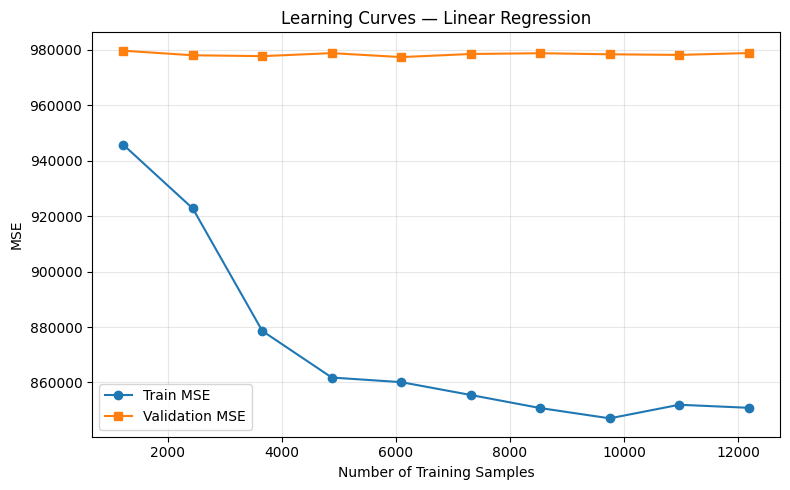

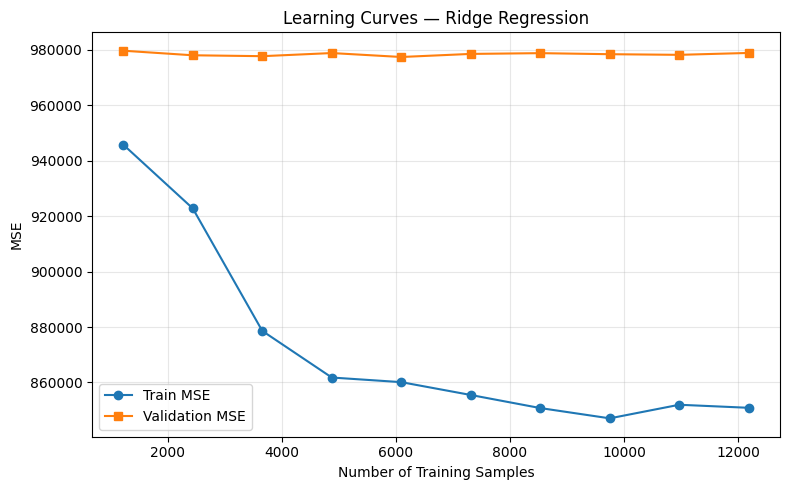

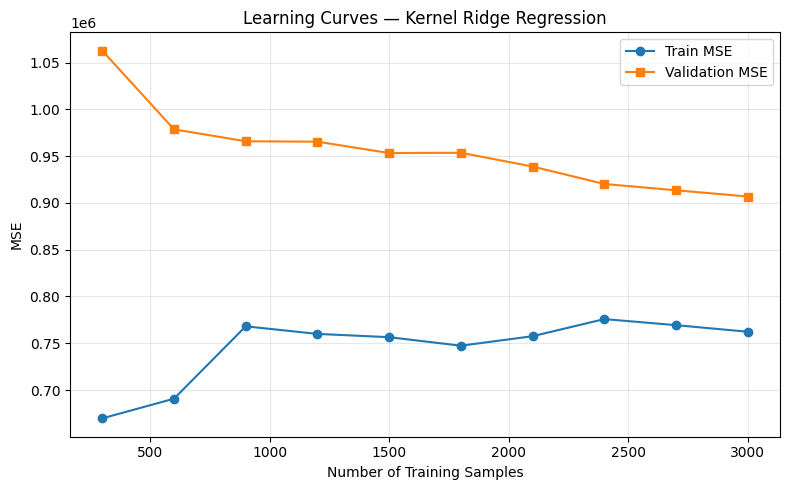

In [37]:
plot_learning_curves(
    LinearRegression, {'solver': 'normal'},
    X_train, y_train, X_val, y_val,
    title='Learning Curves — Linear Regression'
)

plot_learning_curves(
    RidgeRegression, {'alpha': best_alpha_ridge},
    X_train, y_train, X_val, y_val,
    title='Learning Curves — Ridge Regression'
)

plot_learning_curves(
    KernelRidgeRegression,
    {'alpha': best_params_krr[0], 'gamma': best_params_krr[1]},
    X_tr_krr, y_tr_krr, X_val, y_val,
    title='Learning Curves — Kernel Ridge Regression'
)

## Biểu đồ phần dư (Residuals)

In [38]:
def plot_residuals(y_true, y_pred, title=''):
    """Kiểm tra tính ngẫu nhiên của sai số."""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter: residuals vs predicted
    axes[0].scatter(y_pred, residuals, alpha=0.3, s=8)
    axes[0].axhline(0, color='r', linestyle='--')
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title(f'{title} — Residuals vs Predicted')
    axes[0].grid(alpha=0.3)

    # Histogram: residual distribution
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Residual Value')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{title} — Residual Distribution')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

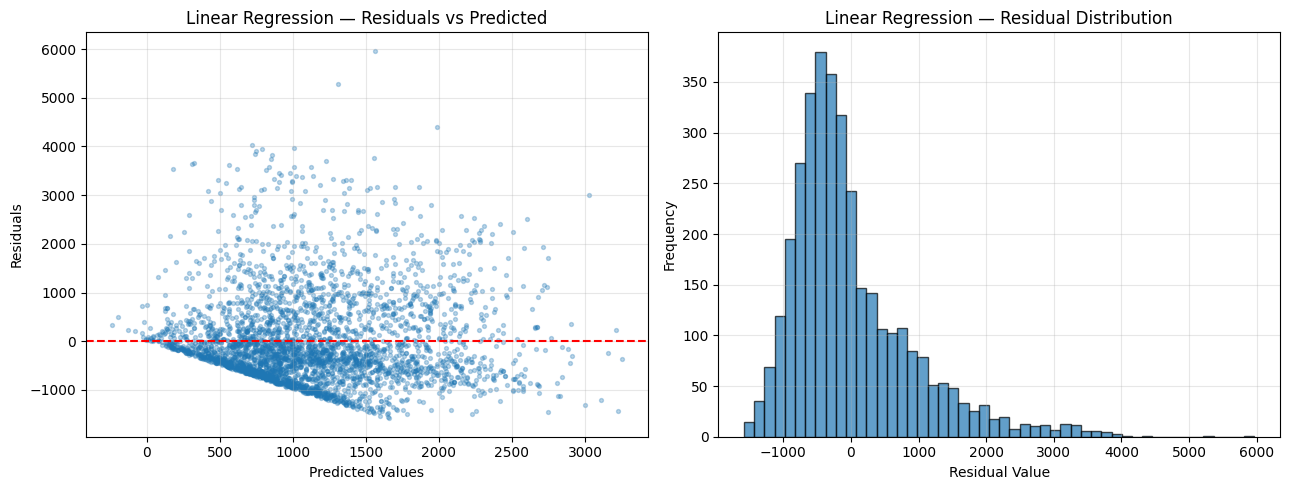

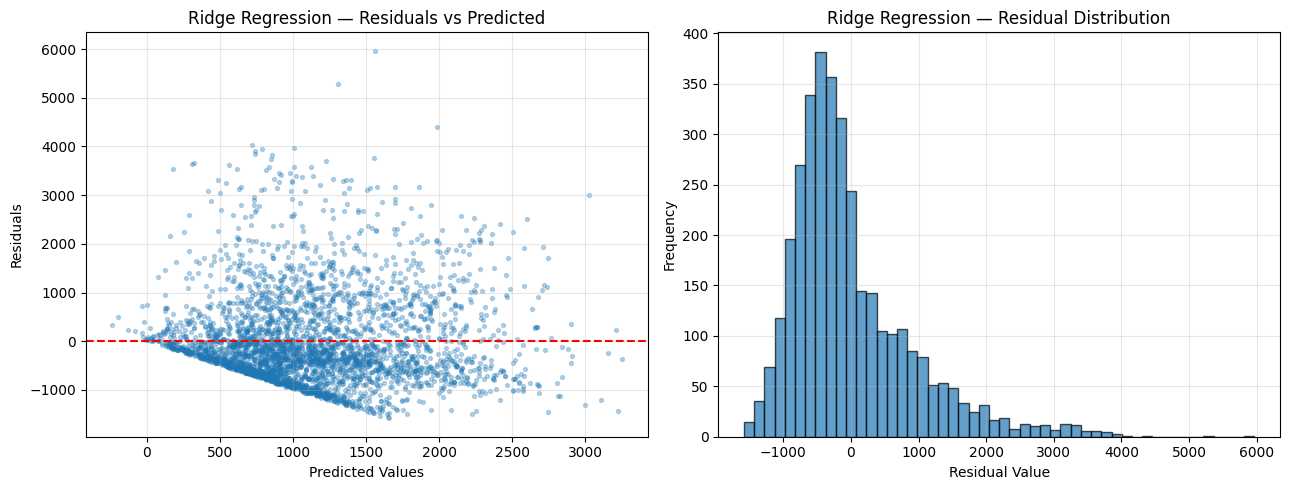

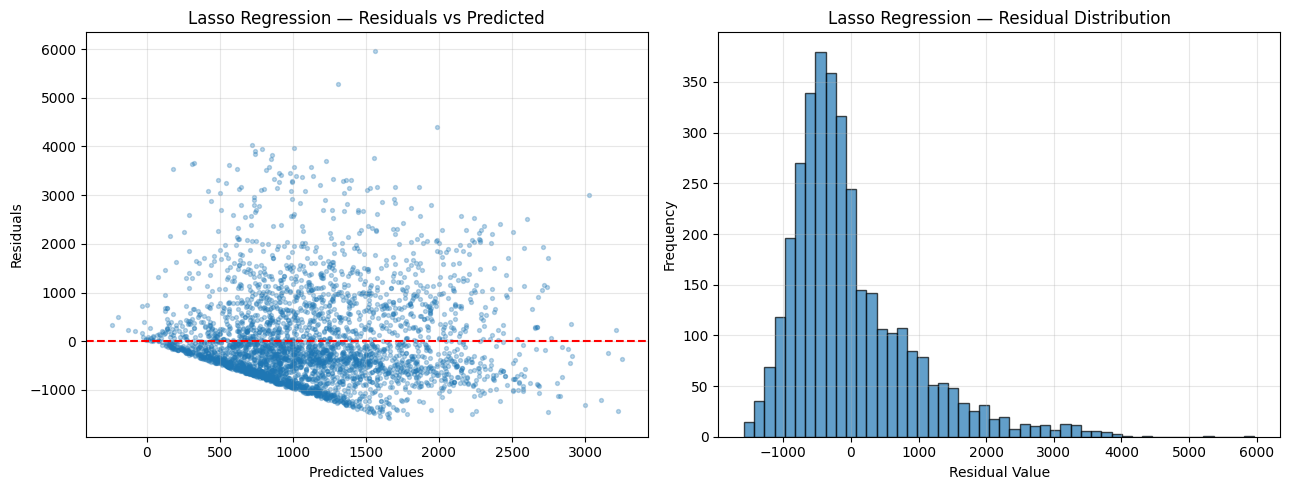

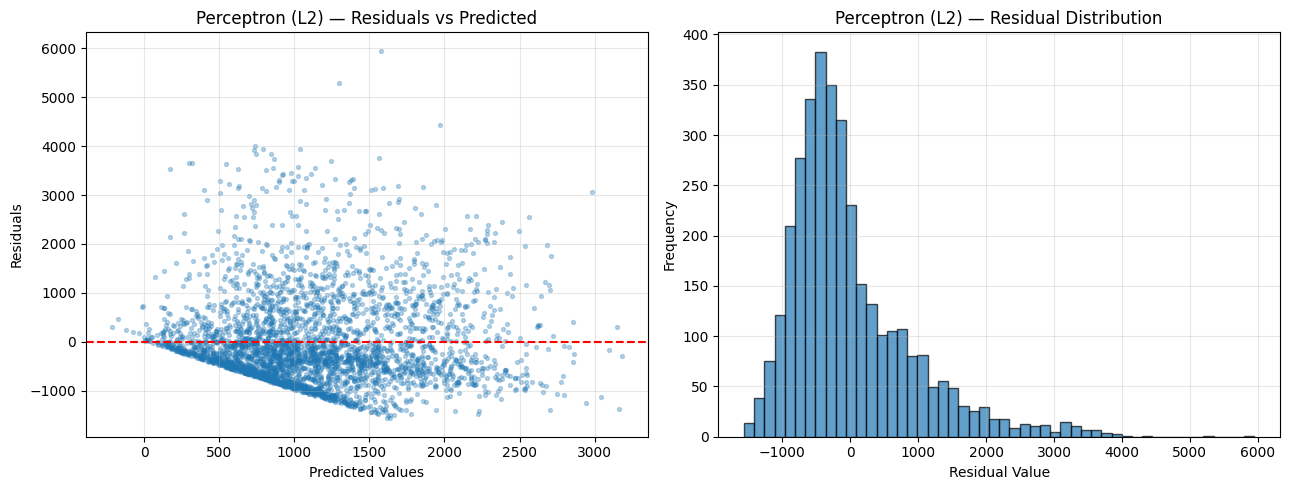

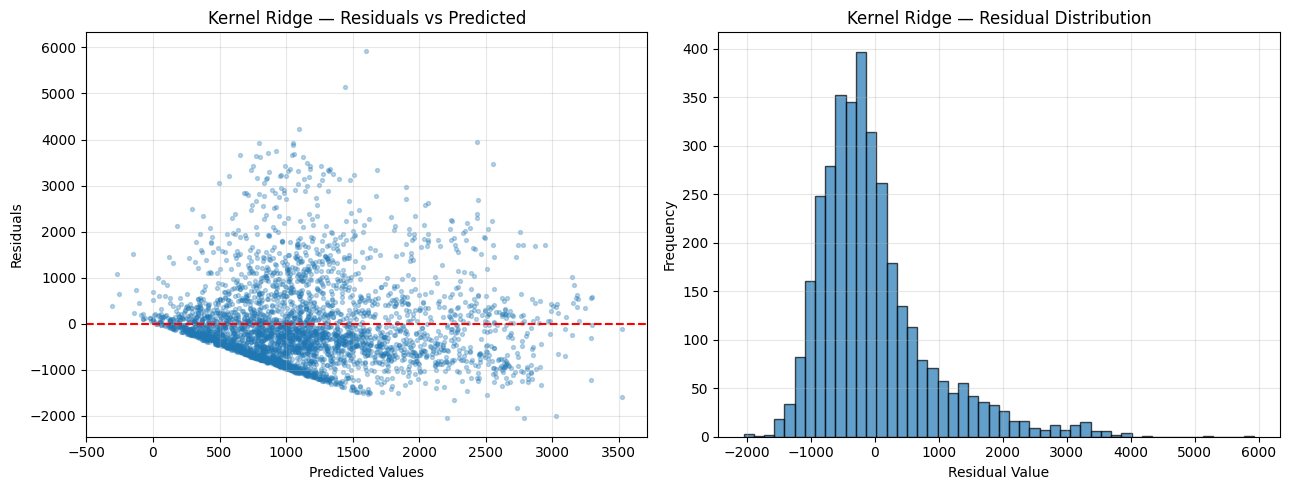

In [39]:
models_pred = [
    ('Linear Regression', y_pred_lr),
    ('Ridge Regression',  y_pred_ridge),
    ('Lasso Regression',  y_pred_lasso),
    ('Perceptron (L2)',   y_pred_perc),
    ('Kernel Ridge',      y_pred_krr),
]

for name, y_pred in models_pred:
    plot_residuals(y_test, y_pred, title=name)

## Predicted vs. Actual

In [40]:
def plot_predicted_vs_actual(y_true, y_pred, title=''):
    """Biểu đồ giá trị dự đoán vs. giá trị thật."""
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.3, s=8)

    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect (y = x)')

    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

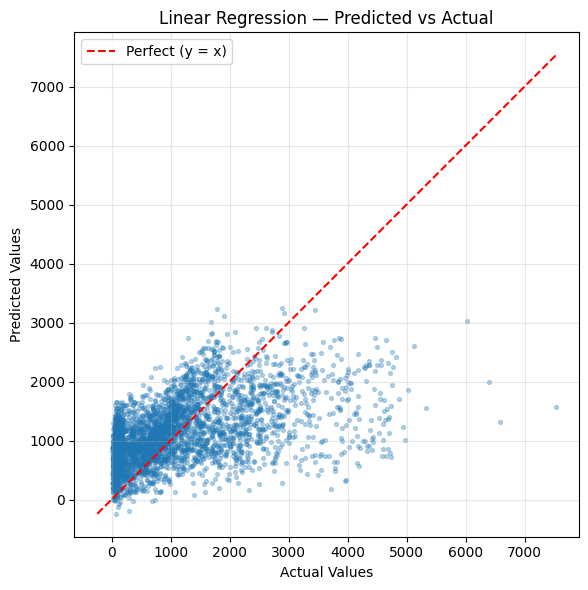

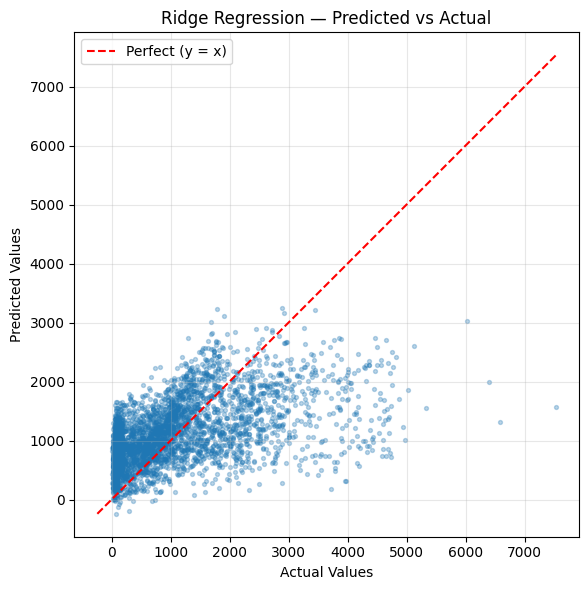

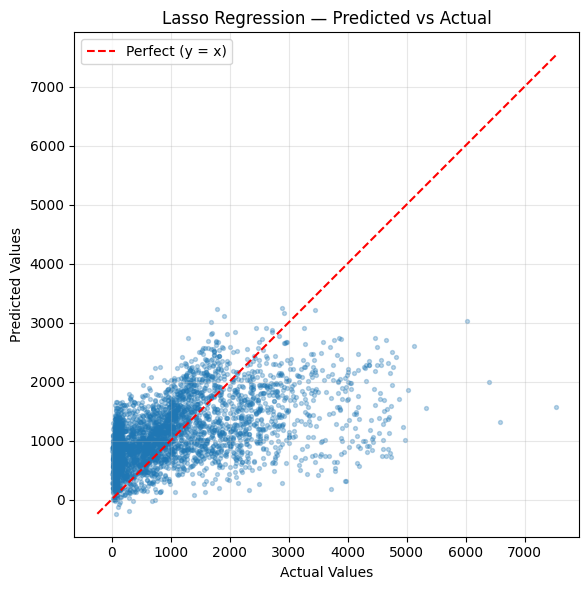

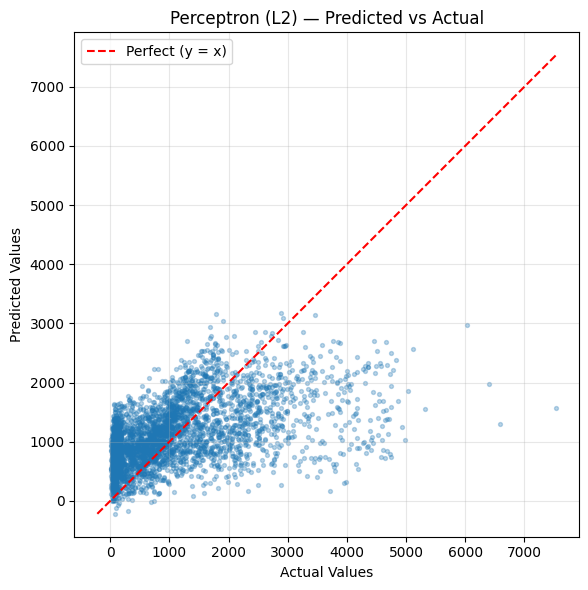

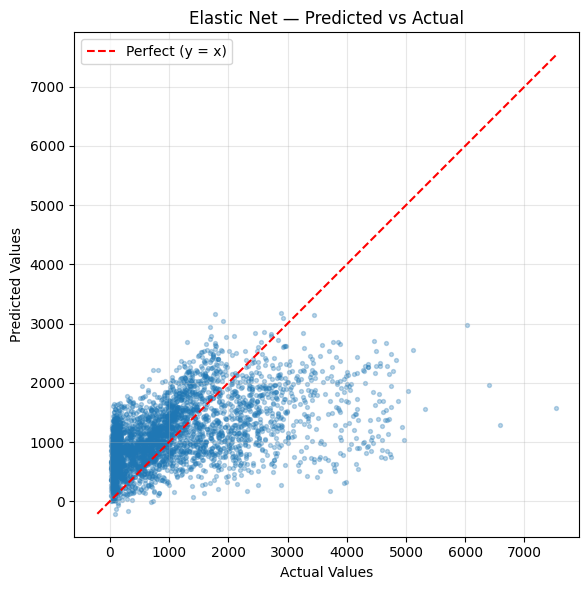

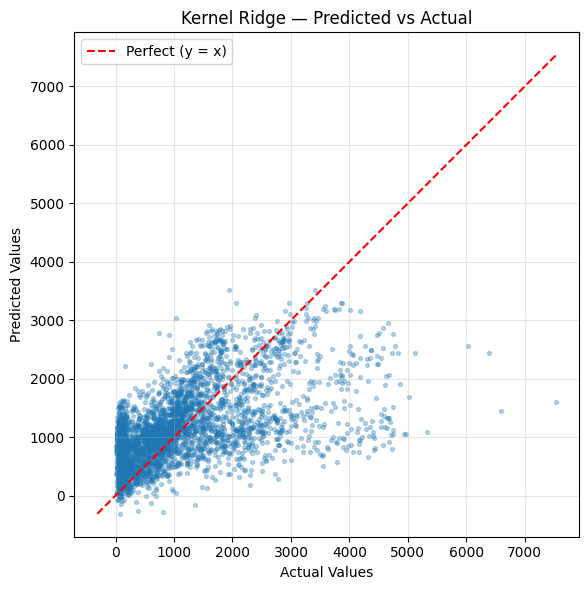

In [41]:
# Tạo danh sách các mô hình và dự đoán
models_pred = [
    ('Linear Regression', y_pred_lr),
    ('Ridge Regression',  y_pred_ridge),
    ('Lasso Regression',  y_pred_lasso),
    ('Perceptron (L2)',   y_pred_perc),
    ('Elastic Net',       y_test_pred_enet),
    ('Kernel Ridge',      y_pred_krr),
]

for name, y_pred in models_pred:
    plot_predicted_vs_actual(y_test, y_pred, title=f'{name} — Predicted vs Actual')